# EDA

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('../data/processed/cars_stage1_cleaned.csv')
df.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Mileage_Unit,Car_Age,Brand
0,Mumbai,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,km/kg,10,Maruti
1,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,kmpl,5,Hyundai
2,Chennai,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,kmpl,9,Honda
3,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,kmpl,8,Maruti
4,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,kmpl,7,Audi


## Price distribution

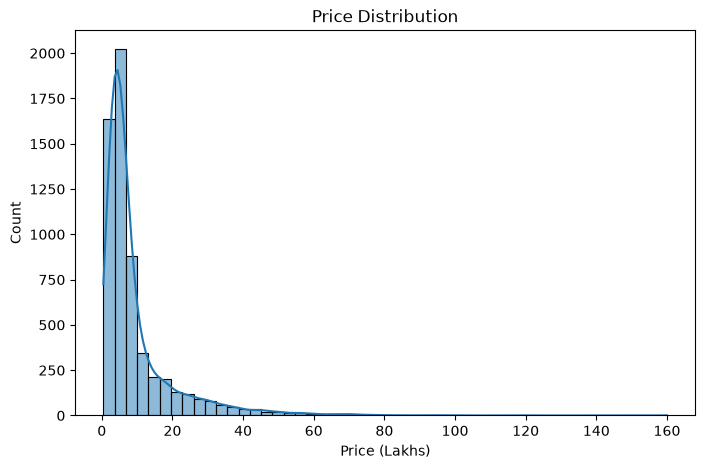

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (Lakhs)')
plt.show()

##### Right-skewed distribution — most cars priced under 15 Lakhs, with a long tail of expensive outliers up to 160 Lakhs.

## Correlation heatmap

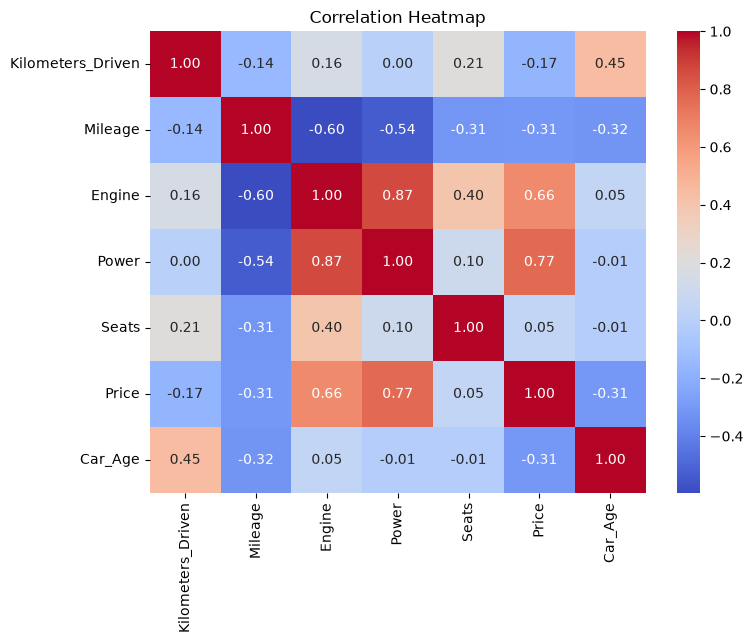

In [19]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### `Power` (0.77) and `Engine` (0.66) are the strongest predictors of `Price`. `Car_Age` and `Mileage` are moderately negative (-0.31 each). `Kilometers_Driven` has almost no linear correlation (-0.01) — surprising, worth exploring further. `Engine` and `Power` are highly correlated with each other (0.87).

## Price vs Kilometers_Driven

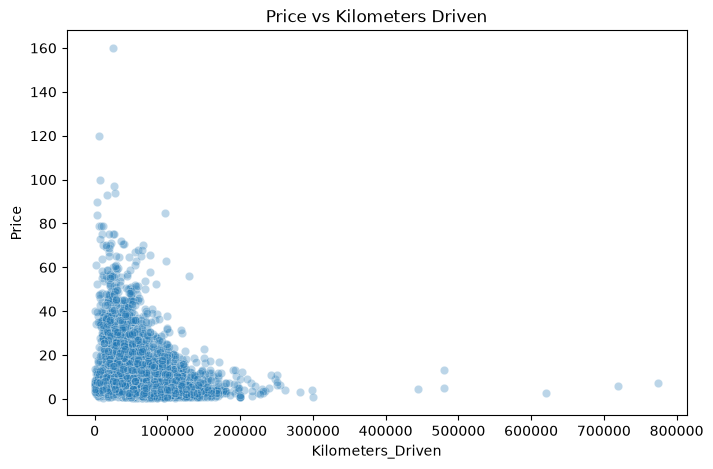

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kilometers_Driven', y='Price', alpha=0.3)
plt.title('Price vs Kilometers Driven')
plt.show()

##### After removing the outlier: x-axis rescales, real spread and downward trend become visible.

## Price by Brand

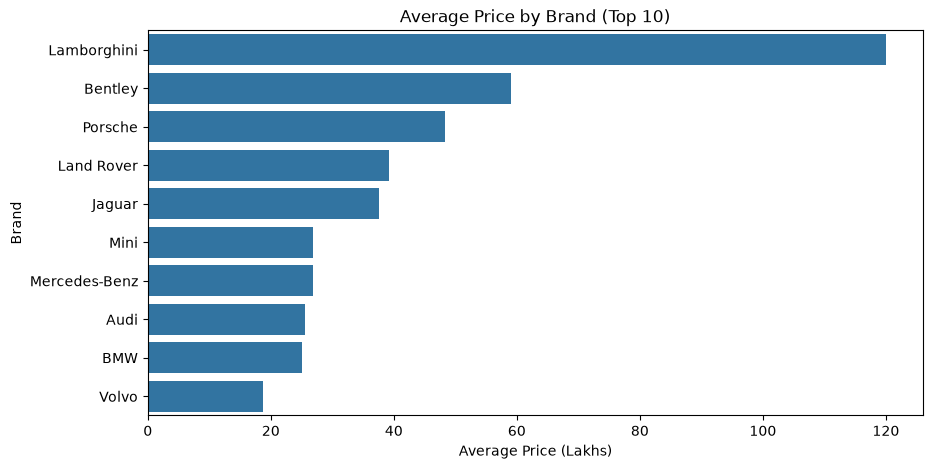

In [21]:
top_brands_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_brands_price.values, y=top_brands_price.index)
plt.title('Average Price by Brand (Top 10)')
plt.xlabel('Average Price (Lakhs)')
plt.show()

##### Top 10 are all luxury/sports brands (Lamborghini, Bentley, Porsche...) — makes sense. Note: these are exactly the brands grouped into "Other" during encoding (rare, <100 occurrences), so the model can't tell them apart — a real limitation for luxury car pricing.

##

## Price by Fuel_Type & Transmission

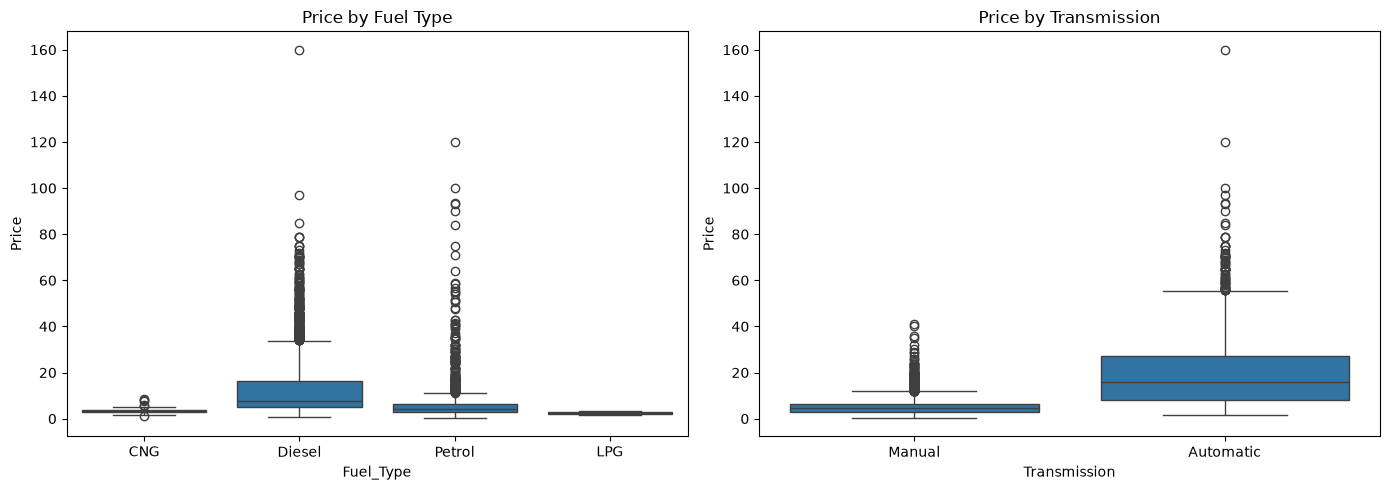

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='Fuel_Type', y='Price', ax=axes[0])
axes[0].set_title('Price by Fuel Type')

sns.boxplot(data=df, x='Transmission', y='Price', ax=axes[1])
axes[1].set_title('Price by Transmission')

plt.tight_layout()
plt.show()

##### Diesel priced higher than Petrol; CNG/LPG cheapest. Automatic cars priced notably higher than Manual across the board.

## Price vs Power

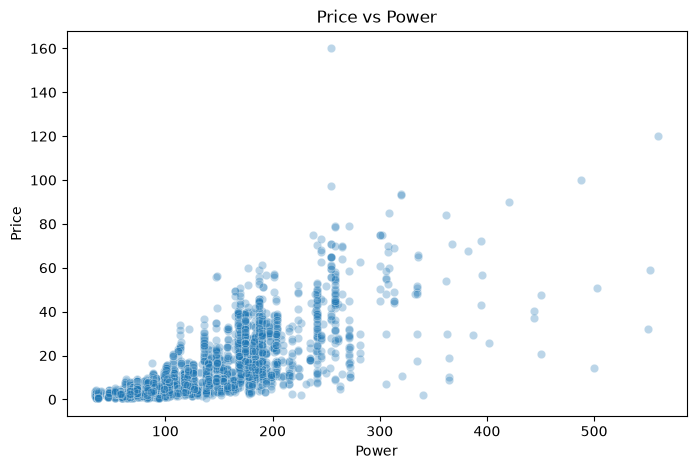

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Power', y='Price', alpha=0.3)
plt.title('Price vs Power')
plt.show()

##### Strong positive relationship, confirming the 0.77 correlation. Variance increases at higher Power — other factors (brand, luxury) dominate pricing at the top end.

## Price vs Car_Age

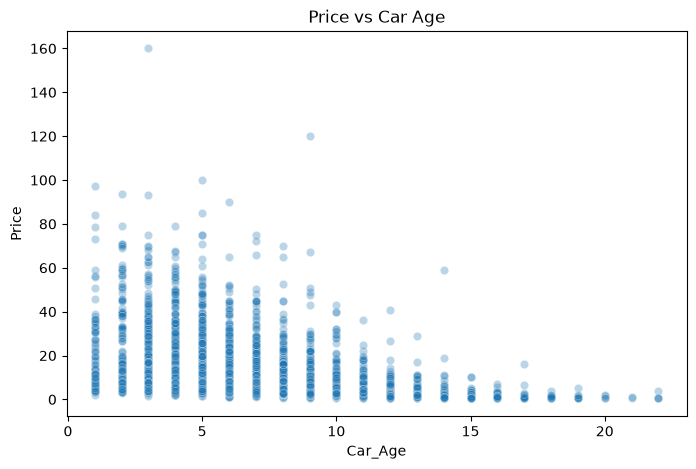

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Car_Age', y='Price', alpha=0.3)
plt.title('Price vs Car Age')
plt.show()

##### Clear negative relationship (confirms -0.31 correlation). Price range narrows drastically with age — cars over 15 years are almost all under 20 Lakhs, regardless of original brand/power.

## Outliers checking

In [27]:
numeric_cols_check = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age', 'Price']

for col in numeric_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.1f} to {upper:.1f})")

Kilometers_Driven: 201 outliers (bounds: -24500.0 to 131500.0)
Mileage: 82 outliers (bounds: 6.3 to 30.0)
Engine: 61 outliers (bounds: 19.0 to 3163.0)
Power: 237 outliers (bounds: -19.6 to 232.8)
Seats: 962 outliers (bounds: 5.0 to 5.0)
Car_Age: 50 outliers (bounds: -3.5 to 16.5)
Price: 717 outliers (bounds: -6.2 to 19.6)


In [28]:
df[df['Kilometers_Driven'] > 131500].sort_values('Kilometers_Driven', ascending=False).head(20)

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Mileage_Unit,Car_Age,Brand
340,Kolkata,775000,Diesel,Automatic,First,19.30,1968.0,141.00,5.0,7.50,kmpl,7,Skoda
1860,Chennai,720000,Diesel,Manual,First,20.54,1598.0,103.60,5.0,5.90,kmpl,7,Volkswagen
358,Chennai,620000,Petrol,Manual,First,20.36,1197.0,78.90,5.0,2.70,kmpl,11,Hyundai
2822,Chennai,480000,Diesel,Automatic,First,16.96,1968.0,138.03,5.0,13.00,kmpl,5,Volkswagen
3091,Kolkata,480000,Petrol,Manual,First,17.40,1497.0,117.30,5.0,5.00,kmpl,5,Honda
4489,Bangalore,445000,Petrol,Manual,First,18.50,1197.0,82.90,5.0,4.45,kmpl,7,Hyundai
3648,Jaipur,300000,Diesel,Manual,First,17.00,1405.0,70.00,5.0,1.00,kmpl,12,Tata
1528,Hyderabad,299322,Diesel,Manual,First,12.80,2494.0,102.00,8.0,4.00,kmpl,15,Toyota
1975,Pune,282000,Petrol,Manual,First,13.14,1798.0,160.00,5.0,3.30,kmpl,8,Skoda
29,Mumbai,262000,Diesel,Manual,Fourth & Above,12.80,2494.0,102.00,7.0,4.00,kmpl,13,Toyota


##### Top 20 values (up to 775K km) are all plausible — high-mileage cars with reasonable age. No further outliers to remove here.